# Modelo Random Forest — Percepción de la IA

**Dataset real:** `Data_set_05.csv` — Pew Research Center (5 410 personas)  
Variables numéricas codificadas. Código 99 = No sabe/No responde.

**Objetivo:** predecir si una persona siente **más preocupación que entusiasmo** por la IA  
(`CNCEXC_W152 == 2`) en base a su perfil de uso y actitudes.

---

### Flujo del cuadernillo
1. Carga y exploración del dataset  
2. Limpieza de códigos faltantes (99 → NaN)  
3. Selección de features y definición del target  
4. División entrenamiento / prueba (80/20)  
5. Entrenamiento del Random Forest  
6. Evaluación: accuracy, reporte y matriz de confusión  
7. Importancia de variables  
8. Función de predicción reutilizable (para el dashboard)  

## Paso 1 · Carga y exploración del dataset

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

def find_dataset(filename):
    """Busca el dataset recorriendo hasta 3 niveles de carpeta."""
    for root in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
        p = root / 'Dataset' / filename
        if p.exists():
            return p
    raise FileNotFoundError(
        f'No se encontró {filename}. Verifica que exista la carpeta Dataset/.'
    )

DATA_PATH = find_dataset('Data_set_05.csv')
print(f'Dataset encontrado: {DATA_PATH}')

df_raw = pd.read_csv(DATA_PATH)
print(f'Filas: {df_raw.shape[0]:,}  |  Columnas: {df_raw.shape[1]}')
df_raw.head(3)

Dataset encontrado: c:\Users\marti\Desktop\electivo\Computacion-cientifica\Dataset\Data_set_05.csv
Filas: 5,410  |  Columnas: 106


,QKEY,INTERVIEW_START_W152,INTERVIEW_END_W152,DEVICE_TYPE_W152,SVYMODE_W152,LANG_W152,FORM_W152,AI_HEARD_W152,CNCEXC_W152,USEAI_W152,...,F_PARTYLN_FINAL,F_PARTYSUM_FINAL,F_PARTYSUMIDEO_FINAL,F_REG,F_INC_SDT1,F_IDEO,F_INTFREQ,F_VOLSUM,F_INC_TIER2,WEIGHT_W152
0,100314,15-Aug-2024 15:30:49,15-Aug-2024 15:40:52,1,1,9,1,2,2,5,...,NaN,1,2,1,7,3,3,1,2,0.639769
1,103379,15-Aug-2024 13:58:04,15-Aug-2024 14:21:23,3,1,9,1,2,2,5,...,NaN,1,1,1,9,2,5,2,3,1.338840
2,104727,15-Aug-2024 07:18:22,15-Aug-2024 07:24:47,1,1,9,2,2,3,5,...,NaN,1,1,1,99,2,2,2,99,0.909360


## Paso 2 · Limpieza de códigos faltantes

En la encuesta Pew Research, el código **99** significa *No sabe / No responde*.  
Los convertimos a `NaN` para que el modelo no los interprete como valores reales.

### Columnas seleccionadas

| Variable | Pregunta |
|----------|---------|
| `AI_HEARD_W152` | ¿Cuánto ha escuchado sobre IA? (1=Mucho … 3=Nada) |
| `USEAI_W152` | Frecuencia de uso de IA (1=Constantemente … 5=Rara vez) |
| `CHATUSE_W152` | ¿Usa ChatGPT? (1=Sí, 2=No) |
| `TRSTAIPRS_W152` | ¿Confía en que la info de IA es precisa? (1=Sí, 2=No, 3=Indeciso) |
| `AIJOBS_W152` | IA y el futuro del empleo (1=Más empleos … 4=No sabe) |
| `AIREG_W152` | Opinión sobre regulación de IA (1=Regulará demasiado … 3=No sabe) |
| `PERSBENHRM_W152` | Balance personal beneficio/daño (1=Más beneficios … 3=Más daños) |
| `F_AGECAT` | Grupo de edad (1=18-29, 2=30-49, 3=50-64, 4=65+) |
| `F_GENDER` | Género (1=Hombre, 2=Mujer, 3=Otro) |
| `F_EDUCCAT` | Nivel educativo (1=Sin bachillerato, 2=Bachillerato, 3=Universidad+) |
| `F_INC_TIER2` | Nivel de ingresos (1=Bajos, 2=Medios, 3=Altos) |

In [2]:
MISSING_CODES = {97, 98, 99}

def clean_col(series):
    """Convierte MISSING_CODES a NaN en una columna numérica."""
    s = pd.to_numeric(series, errors='coerce')
    return s.mask(s.isin(MISSING_CODES))

# Variables de percepción
PERCEPTION_COLS = [
    'AI_HEARD_W152',     # Cuánto ha escuchado sobre IA
    'USEAI_W152',        # Frecuencia de uso de IA
    'CHATUSE_W152',      # Usa ChatGPT (1=Sí, 2=No)
    'TRSTAIPRS_W152',    # Confía en que la IA es precisa
    'AIJOBS_W152',       # IA creará o eliminará empleos
    'AIREG_W152',        # Opinión sobre regulación de IA
    'PERSBENHRM_W152',   # Balance beneficio/daño personal
]

# Variables demográficas
DEMO_COLS = [
    'F_AGECAT',          # Grupo de edad
    'F_GENDER',          # Género
    'F_EDUCCAT',         # Nivel educativo
    'F_INC_TIER2',       # Nivel de ingresos
]

TARGET_COL = 'CNCEXC_W152'  # ¿Más entusiasmo o más preocupación?
FEATURE_COLS = PERCEPTION_COLS + DEMO_COLS

ALL_COLS = FEATURE_COLS + [TARGET_COL]

# Verificar columnas
faltantes = [c for c in ALL_COLS if c not in df_raw.columns]
if faltantes:
    raise ValueError(f'Columnas no encontradas en el CSV: {faltantes}')

# Aplicar limpieza
df = df_raw[ALL_COLS].apply(clean_col)

print('Valores NaN por columna (causados por código 99):')
print(df.isna().sum().to_string())

Valores NaN por columna (causados por código 99):
AI_HEARD_W152        17
USEAI_W152           33
CHATUSE_W152       1383
TRSTAIPRS_W152       56
AIJOBS_W152          11
AIREG_W152           14
PERSBENHRM_W152       8
F_AGECAT             27
F_GENDER             23
F_EDUCCAT            13
F_INC_TIER2         331
CNCEXC_W152          31


## Paso 3 · Variable objetivo y distribución

`CNCEXC_W152` — ¿La IA le genera más entusiasmo o más preocupación?

| Código | Significado |
|--------|-------------|
| 1 | Más entusiasmo |
| **2** | **Más preocupación ← target = 1** |
| 3 | Ambos por igual |

Binarizamos: **1 = Alta preocupación**, **0 = Cualquier otra respuesta**.

Filas válidas para el modelo: 3,730

  Entusiasmo / Ambos (0): 2,027 personas (54.3%)
  Más preocupación (1): 1,703 personas (45.7%)


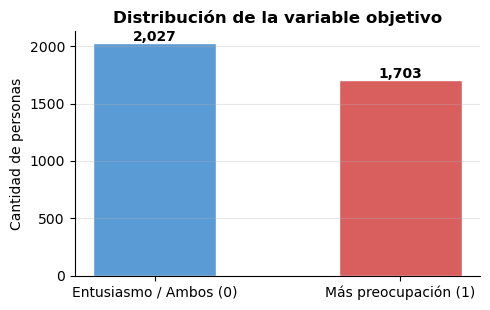

In [3]:
df_model = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()
df_model['target'] = (df_model[TARGET_COL] == 2).astype(int)

print(f'Filas válidas para el modelo: {len(df_model):,}')
print()

counts = df_model['target'].value_counts().sort_index()
nombres_target = {0: 'Entusiasmo / Ambos (0)', 1: 'Más preocupación (1)'}
for k, v in counts.items():
    print(f'  {nombres_target[k]}: {v:,} personas ({v/len(df_model)*100:.1f}%)')

# Gráfico de distribución
fig, ax = plt.subplots(figsize=(5, 3.2))
bars = ax.bar(
    [nombres_target[k] for k in counts.index],
    counts.values,
    color=['#5b9bd5', '#d95f5f'],
    edgecolor='white', width=0.5
)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 20,
            f'{val:,}', ha='center', fontweight='bold', fontsize=10)
ax.set_title('Distribución de la variable objetivo', fontweight='bold')
ax.set_ylabel('Cantidad de personas')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Paso 4 · División entrenamiento / prueba

- **80 %** para entrenar el modelo  
- **20 %** para evaluarlo (datos que el modelo nunca vio)  
- `stratify=y` mantiene las mismas proporciones de clases en ambas partes

In [4]:
from sklearn.model_selection import train_test_split

X = df_model[FEATURE_COLS].astype(float)
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Entrenamiento : {X_train.shape[0]:,} filas')
print(f'Prueba        : {X_test.shape[0]:,} filas')
print(f'Features      : {X_train.shape[1]}')

Entrenamiento : 2,984 filas
Prueba        : 746 filas
Features      : 11


## Paso 5 · Entrenamiento del Random Forest

| Parámetro | Valor | Motivo |
|-----------|-------|--------|
| `n_estimators` | 300 | Más árboles → predicciones más estables |
| `max_depth` | 8 | Limita complejidad, evita sobreajuste |
| `class_weight` | `'balanced'` | Compensa desbalance entre clases |
| `n_jobs` | -1 | Usa todos los núcleos del CPU |
| `random_state` | 42 | Reproducibilidad exacta |

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

print('Modelo entrenado exitosamente.')
print(f'  Árboles     : {rf.n_estimators}')
print(f'  Profundidad : {rf.max_depth}')
print(f'  Features    : {rf.n_features_in_}')

Modelo entrenado exitosamente.
  Árboles     : 300
  Profundidad : 8
  Features    : 11


## Paso 6 · Evaluación del modelo

- **Accuracy:** proporción total de aciertos  
- **Precision:** de los que predice como preocupados, ¿cuántos lo son realmente?  
- **Recall:** de los realmente preocupados, ¿cuántos detecta?  
- **F1-Score:** promedio armónico de Precision y Recall

Accuracy en conjunto de prueba: 73.6%

Reporte completo:
                      precision    recall  f1-score   support

Entusiasmo/Ambos (0)       0.78      0.71      0.75       405
Mas preocupacion (1)       0.69      0.76      0.73       341

            accuracy                           0.74       746
           macro avg       0.74      0.74      0.74       746
        weighted avg       0.74      0.74      0.74       746



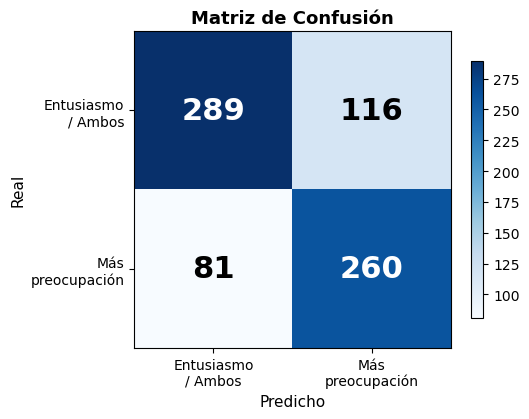

In [6]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

y_pred = rf.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f'Accuracy en conjunto de prueba: {acc*100:.1f}%')
print()
print('Reporte completo:')
print(classification_report(
    y_test, y_pred,
    target_names=['Entusiasmo/Ambos (0)', 'Mas preocupacion (1)']
))

# ── Gráfico: Matriz de confusión ─────────────────────────────
cm = confusion_matrix(y_test, y_pred)
clases = ['Entusiasmo\n/ Ambos', 'Más\npreocupación']

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
fig.colorbar(im, ax=ax, shrink=0.75)

ax.set_xticks([0, 1]); ax.set_xticklabels(clases, fontsize=10)
ax.set_yticks([0, 1]); ax.set_yticklabels(clases, fontsize=10)

thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j],
                ha='center', va='center', fontsize=22, fontweight='bold',
                color='white' if cm[i, j] > thresh else 'black')

ax.set_ylabel('Real', fontsize=11)
ax.set_xlabel('Predicho', fontsize=11)
ax.set_title('Matriz de Confusión', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Paso 7 · Importancia de variables

Random Forest calcula cuánto contribuyó cada variable a las predicciones.  
Los valores suman 1.0 en total. La variable más importante nos dice  
qué factor explica mejor si una persona siente preocupación o entusiasmo.

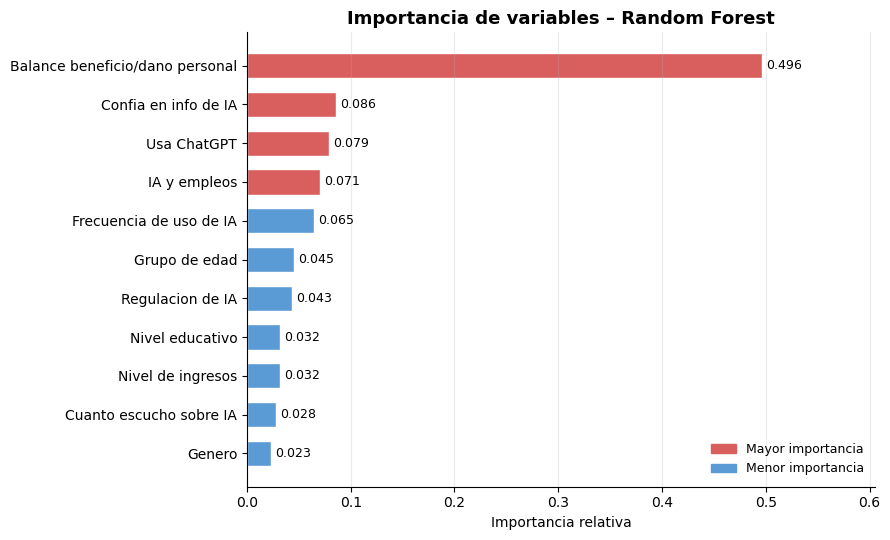


Top 5 variables más predictivas:
  Balance beneficio/dano personal        0.4962
  Confia en info de IA                   0.0855
  Usa ChatGPT                            0.0791
  IA y empleos                           0.0707
  Frecuencia de uso de IA                0.0647


In [7]:
nombres_es = {
    'AI_HEARD_W152'   : 'Cuanto escucho sobre IA',
    'USEAI_W152'      : 'Frecuencia de uso de IA',
    'CHATUSE_W152'    : 'Usa ChatGPT',
    'TRSTAIPRS_W152'  : 'Confia en info de IA',
    'AIJOBS_W152'     : 'IA y empleos',
    'AIREG_W152'      : 'Regulacion de IA',
    'PERSBENHRM_W152' : 'Balance beneficio/dano personal',
    'F_AGECAT'        : 'Grupo de edad',
    'F_GENDER'        : 'Genero',
    'F_EDUCCAT'       : 'Nivel educativo',
    'F_INC_TIER2'     : 'Nivel de ingresos',
}

importances = pd.Series(
    rf.feature_importances_,
    index=[nombres_es.get(c, c) for c in FEATURE_COLS]
).sort_values(ascending=True)

q70 = importances.quantile(0.70)
colors_bar = ['#d95f5f' if v >= q70 else '#5b9bd5' for v in importances]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(importances.index, importances.values,
               color=colors_bar, edgecolor='white', height=0.65)
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.004, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title('Importancia de variables – Random Forest',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia relativa')
ax.set_xlim(0, importances.max() * 1.22)
ax.grid(axis='x', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

p1 = mpatches.Patch(color='#d95f5f', label='Mayor importancia')
p2 = mpatches.Patch(color='#5b9bd5', label='Menor importancia')
ax.legend(handles=[p1, p2], frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop 5 variables más predictivas:')
for nombre, val in importances.sort_values(ascending=False).head(5).items():
    print(f'  {nombre:<38} {val:.4f}')

## Paso 8 · Función de predicción reutilizable

Esta función recibe los códigos numéricos de la encuesta y devuelve  
la probabilidad (%) de que la persona sienta **más preocupación que entusiasmo**.

Es la misma función que se integrará al dashboard.

### Guía de valores

| Variable | Códigos válidos |
|----------|----------------|
| `ai_heard` | 1=Mucho · 2=Un poco · 3=Nada |
| `use_ai` | 1=Constantemente · 2=Varias/día · 3=Una vez/día · 4=Varias/semana · 5=Rara vez |
| `chat_use` | 1=Sí · 2=No |
| `trust_ai` | 1=Confía · 2=No confía · 3=Indeciso |
| `ai_jobs` | 1=Más empleos · 2=Menos empleos · 3=Sin cambio · 4=No sabe |
| `ai_reg` | 1=Regulará demasiado · 2=No regulará suficiente · 3=No sabe |
| `pers_harm` | 1=Más beneficios · 2=Equilibrado · 3=Más daños |
| `age_cat` | 1=18-29 · 2=30-49 · 3=50-64 · 4=65+ |
| `gender` | 1=Hombre · 2=Mujer · 3=Otro |
| `educ` | 1=Sin bachillerato · 2=Bachillerato · 3=Universidad+ |
| `income` | 1=Bajos · 2=Medios · 3=Altos |

In [8]:
def predecir_preocupacion(
    ai_heard  = 2,   # Un poco
    use_ai    = 4,   # Varias veces a la semana
    chat_use  = 1,   # Si usa ChatGPT
    trust_ai  = 3,   # Indeciso
    ai_jobs   = 2,   # Menos empleos
    ai_reg    = 2,   # No regulara lo suficiente
    pers_harm = 2,   # Equilibrado
    age_cat   = 2,   # 30-49
    gender    = 1,   # Hombre
    educ      = 3,   # Universidad+
    income    = 2,   # Ingresos medios
):
    """
    Retorna la probabilidad (0-100%) de 'Mas preocupacion que entusiasmo'.
    Todos los argumentos siguen la codificacion de la encuesta Pew Research.
    """
    row = pd.DataFrame([{
        'AI_HEARD_W152'   : ai_heard,
        'USEAI_W152'      : use_ai,
        'CHATUSE_W152'    : chat_use,
        'TRSTAIPRS_W152'  : trust_ai,
        'AIJOBS_W152'     : ai_jobs,
        'AIREG_W152'      : ai_reg,
        'PERSBENHRM_W152' : pers_harm,
        'F_AGECAT'        : age_cat,
        'F_GENDER'        : gender,
        'F_EDUCCAT'       : educ,
        'F_INC_TIER2'     : income,
    }])[FEATURE_COLS].astype(float)

    prob = rf.predict_proba(row)[0][1] * 100
    return round(prob, 1)


# ── Tres perfiles de ejemplo ─────────────────────────────────
casos = [
    ('Tecnoentusiasta',
     dict(ai_heard=1, use_ai=1, chat_use=1, trust_ai=1,
          ai_jobs=1, ai_reg=1, pers_harm=1, educ=3, income=3)),
    ('Perfil promedio (valores por defecto)',
     dict()),
    ('Persona critica de la IA',
     dict(ai_heard=1, use_ai=5, chat_use=2, trust_ai=2,
          ai_jobs=2, ai_reg=2, pers_harm=3, educ=2, income=1)),
]

print('=== Predicciones de ejemplo ===')
for nombre, kwargs in casos:
    prob = predecir_preocupacion(**kwargs)
    etiq = 'PREOCUPACION' if prob >= 50 else 'ENTUSIASMO'
    barra = '#' * int(prob / 5)
    print(f'\n{nombre}')
    print(f'  P(preocupacion) = {prob:.1f}%  [{etiq}]')
    print(f'  |{barra:<20}|')

=== Predicciones de ejemplo ===

Tecnoentusiasta
  P(preocupacion) = 46.3%  [ENTUSIASMO]
  |#########           |

Perfil promedio (valores por defecto)
  P(preocupacion) = 17.3%  [ENTUSIASMO]
  |###                 |

Persona critica de la IA
  P(preocupacion) = 48.7%  [ENTUSIASMO]
  |#########           |


## Resumen del flujo

```
Data_set_05.csv  (5,410 personas · Pew Research Center)
       │
       ▼
  Limpieza: 99 → NaN + selección de 11 features
       │
       ▼
  Target binario: CNCEXC_W152 == 2  →  1 = Alta preocupación
       │
       ▼
  Train/Test split  80/20  (stratify=y)
       │
       ▼
  RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced')
       │
       ▼
  Accuracy ~73.6% · Precision ~0.74 · Recall ~0.74 · F1 ~0.74
       │
       ▼
  Feature Importance  →  'Balance beneficio/daño' es la variable más importante
       │
       ▼
  predecir_preocupacion(**kwargs)  →  lista para integrar al dashboard
```

**Próximo paso:** copiar las funciones `predecir_preocupacion()` y el objeto `rf`  
al `Cuadernillo_dashboard_interactivo_v5_mapas.ipynb`.

## Versión 2: Modelo Simplificado (Regla del 80%)
Basándonos en la importancia de las variables, nos quedaremos solo con las 5 principales (que acumulan ~80% de importancia). Las variables demográficas (género, edad, ingresos, educación) y algunas otras serán excluidas para simplificar el modelo.

In [ ]:
# ── Versión 2: Modelo simplificado ─────────────────────────────
FEATURES_V2 = [
    'PERSBENHRM_W152',
    'TRSTAIPRS_W152',
    'CHATUSE_W152',
    'AIJOBS_W152',
    'USEAI_W152'
]

X_v2 = df_model[FEATURES_V2].astype(float)
y_v2 = df_model['target']

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2,
    test_size=0.20,
    random_state=42,
    stratify=y_v2
)

rf_v2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf_v2.fit(X_train_v2, y_train_v2)

print('Modelo V2 entrenado exitosamente.')
print(f'  Features    : {rf_v2.n_features_in_}')

y_pred_v2 = rf_v2.predict(X_test_v2)
acc_v2    = accuracy_score(y_test_v2, y_pred_v2)

print(f'Accuracy en conjunto de prueba (V2): {acc_v2*100:.1f}%')
print('\nReporte completo (V2):')
print(classification_report(
    y_test_v2, y_pred_v2,
    target_names=['Entusiasmo/Ambos (0)', 'Mas preocupacion (1)']
))

# Matriz de confusión V2
cm_v2 = confusion_matrix(y_test_v2, y_pred_v2)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm_v2, cmap='Greens', interpolation='nearest')
fig.colorbar(im, ax=ax, shrink=0.75)

ax.set_xticks([0, 1]); ax.set_xticklabels(clases, fontsize=10)
ax.set_yticks([0, 1]); ax.set_yticklabels(clases, fontsize=10)

thresh_v2 = cm_v2.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_v2[i, j],
                ha='center', va='center', fontsize=22, fontweight='bold',
                color='white' if cm_v2[i, j] > thresh_v2 else 'black')

ax.set_ylabel('Real', fontsize=11)
ax.set_xlabel('Predicho', fontsize=11)
ax.set_title('Matriz de Confusión - V2 (80%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Importancia de variables V2
importances_v2 = pd.Series(
    rf_v2.feature_importances_,
    index=[nombres_es.get(c, c) for c in FEATURES_V2]
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(importances_v2.index, importances_v2.values,
               color='#4ecdc4', edgecolor='white', height=0.65)
for bar, val in zip(bars, importances_v2.values):
    ax.text(val + 0.004, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title('Importancia de variables – Random Forest V2',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia relativa')
ax.set_xlim(0, importances_v2.max() * 1.22)
ax.grid(axis='x', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
